In [2]:
# LOAD Packages (copied from initial training script)
import numpy as np
from collections import namedtuple, OrderedDict

import matplotlib
from mpl_toolkits.mplot3d import Axes3D
import os
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import json
import h5py
import glob
import sys
from mpl_toolkits.axes_grid1 import make_axes_locatable
#!pip install plotly
import plotly
import plotly.graph_objects as go

#import MinkowskiEngine as ME
#sys.path.insert(0, '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/spine/')
#from spine.model.layer.cnn.encoder import SparseResidualEncoder

#sys.path.insert(0, '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/')
#import models.sheep_cnn
#sys.path.insert(0, '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/utils')
#from parse_yaml import ParseYAML

#import gc

#gc.collect()
#torch.cuda.empty_cache()

In [70]:
#batch_stats_log = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_ON_MESYNCBN_MOMENTUM_0.1_LOG_BATCH_STATS/logs/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_ON_MESYNCBN_MOMENTUM_0.1_LOG_BATCH_STATS_default_batch_stats_log.csv'
#train_log = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_ON_MESYNCBN_MOMENTUM_0.1_LOG_BATCH_STATS/logs/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_ON_MESYNCBN_MOMENTUM_0.1_LOG_BATCH_STATS_default_train_log.csv'

# Momentum NONE, LR 0.0001, Batch Size 3125
#batch_stats_log = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_ON_MESYNCBN_MOMENTUM_NONE_LOG_BATCH_STATS_BS_3125_num_workers_16_LR_0.0001/logs/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_ON_MESYNCBN_MOMENTUM_NONE_LOG_BATCH_STATS_BS_3125_num_workers_16_LR_0.0001_default_batch_stats_log.csv'
#train_log = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_ON_MESYNCBN_MOMENTUM_NONE_LOG_BATCH_STATS_BS_3125_num_workers_16_LR_0.0001/logs/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_ON_MESYNCBN_MOMENTUM_NONE_LOG_BATCH_STATS_BS_3125_num_workers_16_LR_0.0001_default_train_log.csv'

# Momentum 0.01, LR 0.0001, Batch Size 3125
batch_stats_log = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_ON_MESYNCBN_MOMENTUM_0.01_LOG_BATCH_STATS_BS_3125_num_workers_16_LR_0.0001/logs/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_ON_MESYNCBN_MOMENTUM_0.01_LOG_BATCH_STATS_BS_3125_num_workers_16_LR_0.0001_default_batch_stats_log.csv'
train_log = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_ON_MESYNCBN_MOMENTUM_0.01_LOG_BATCH_STATS_BS_3125_num_workers_16_LR_0.0001/logs/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_ON_MESYNCBN_MOMENTUM_0.01_LOG_BATCH_STATS_BS_3125_num_workers_16_LR_0.0001_default_train_log.csv'

# Momentum NONE, LR 0.001, Batch Size 3125
#batch_stats_log = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_ON_MESYNCBN_MOMENTUM_NONE_LOG_BATCH_STATS_BS_3125_num_workers_16/logs/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_ON_MESYNCBN_MOMENTUM_NONE_LOG_BATCH_STATS_BS_3125_num_workers_16_default_batch_stats_log.csv'
#train_log = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_ON_MESYNCBN_MOMENTUM_NONE_LOG_BATCH_STATS_BS_3125_num_workers_16/logs/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_ON_MESYNCBN_MOMENTUM_NONE_LOG_BATCH_STATS_BS_3125_num_workers_16_default_train_log.csv'

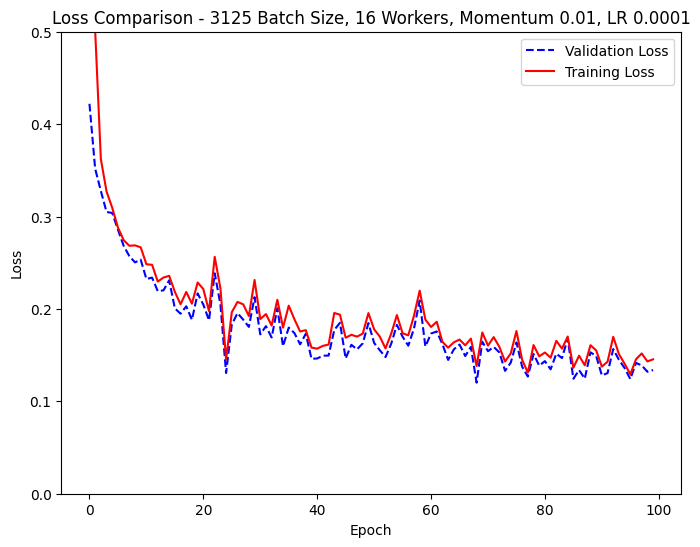

In [73]:
import csv


def plot_train_val_loss(log_file, title):

    epochs = []
    val_loss = []
    train_loss = []
    with open(log_file, 'r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            epochs.append(int(row['epoch']))
            val_loss.append(float(row['val_loss']))
            train_loss.append(float(row['train_loss']))

    fig, ax = plt.subplots(figsize=(8,6))
    ax.plot(epochs, val_loss, label='Validation Loss', color='blue', linestyle='--')
    ax.plot(epochs, train_loss, label='Training Loss', color='red', linestyle='-')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Loss Comparison - ' + title)
    ax.legend()
    ax.set_ylim(0, 0.5)
    #ax.set_yscale('log')
    plt.show()

plot_train_val_loss(train_log, title='3125 Batch Size, 16 Workers, Momentum 0.01, LR 0.0001')

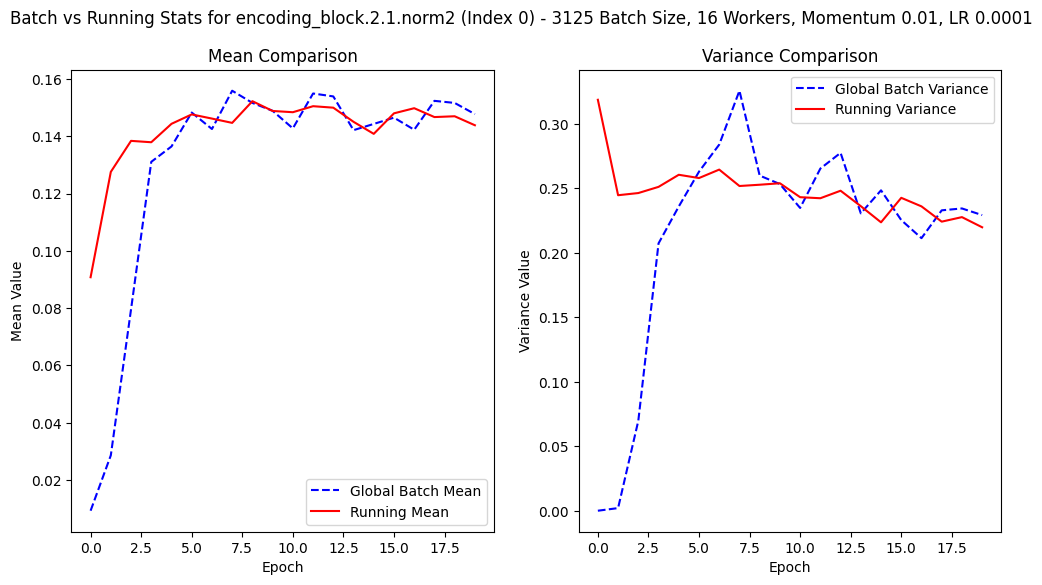

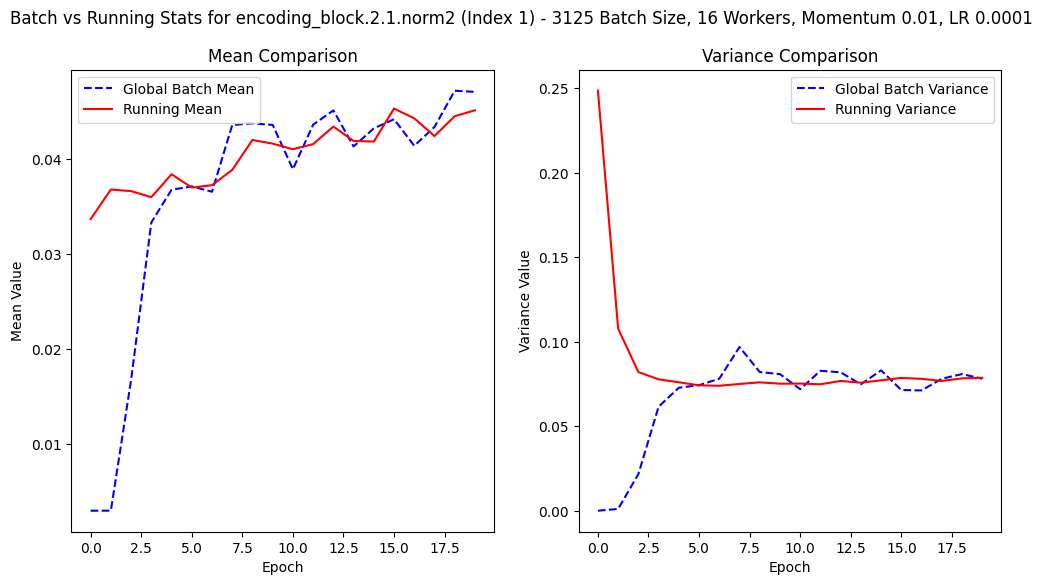

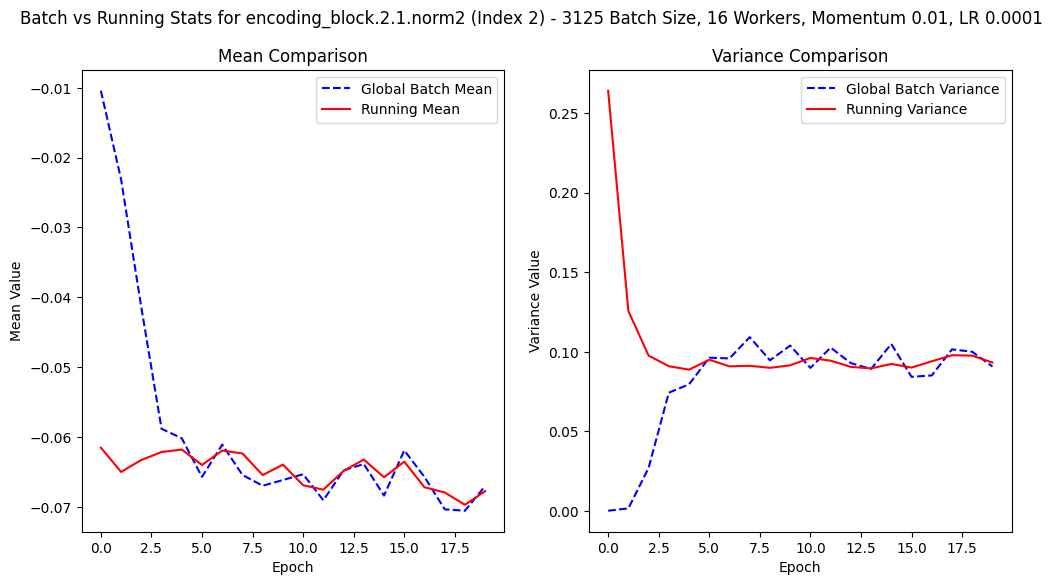

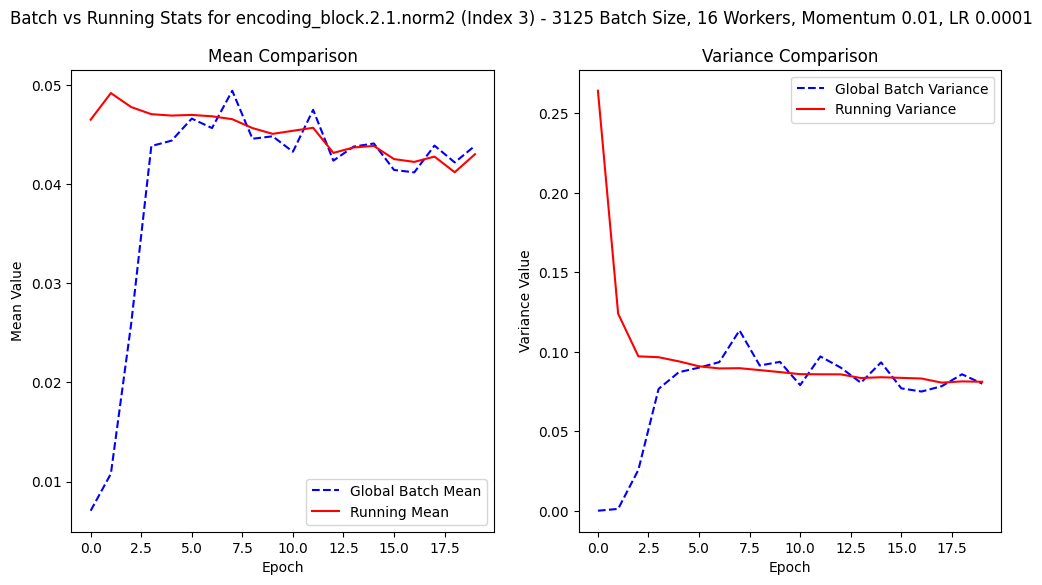

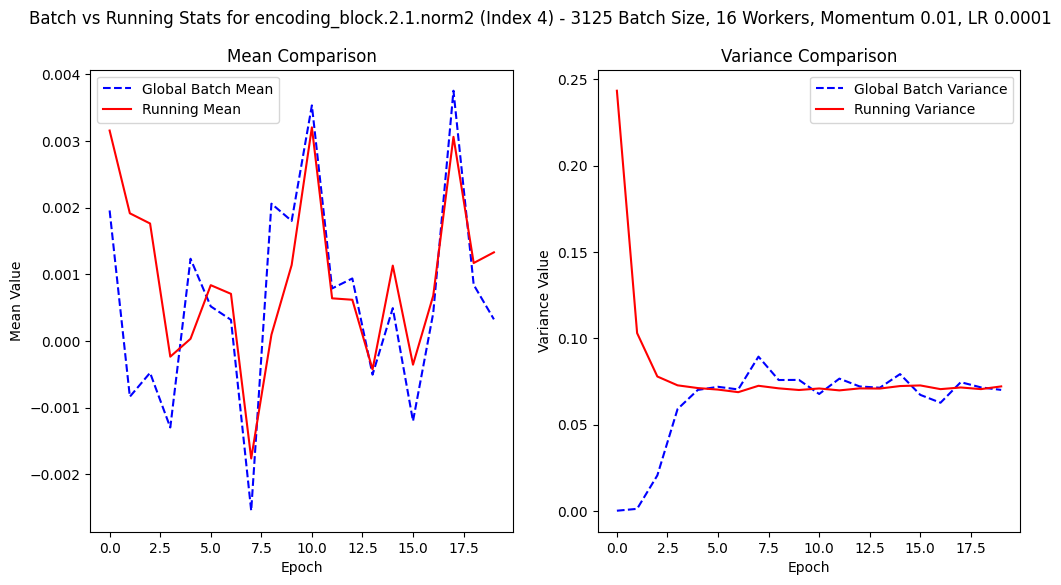

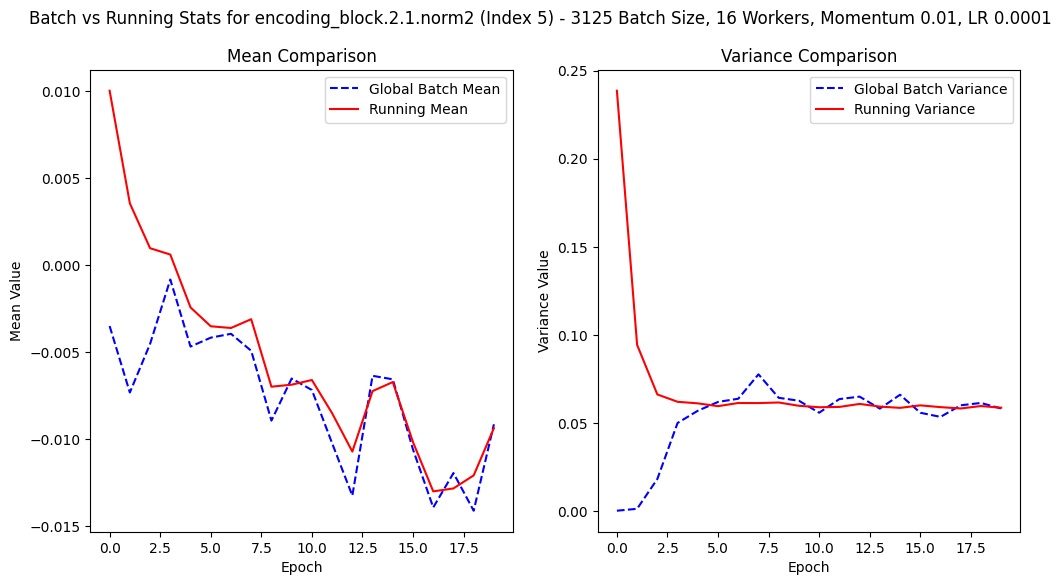

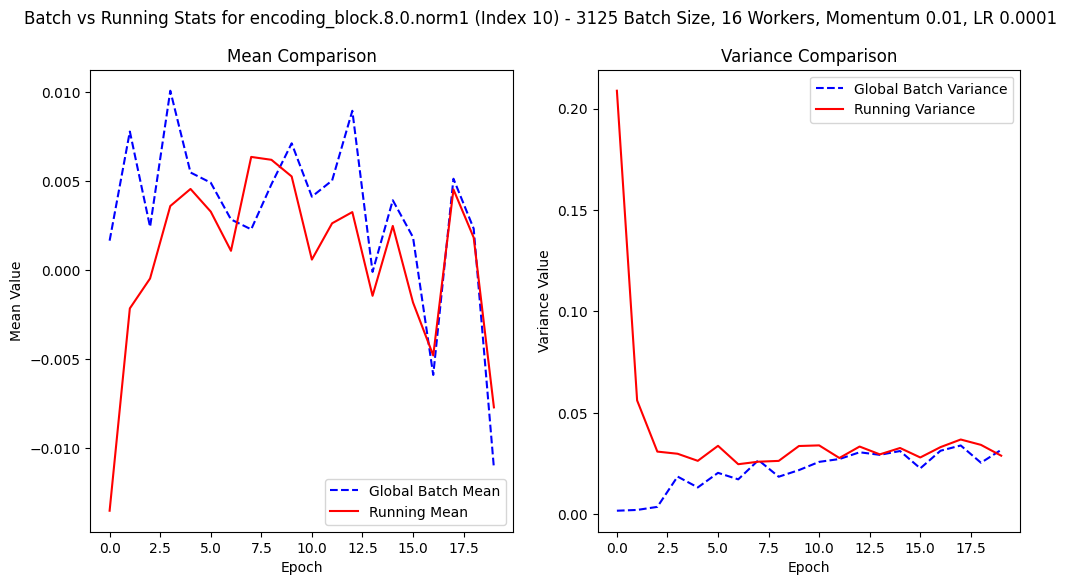

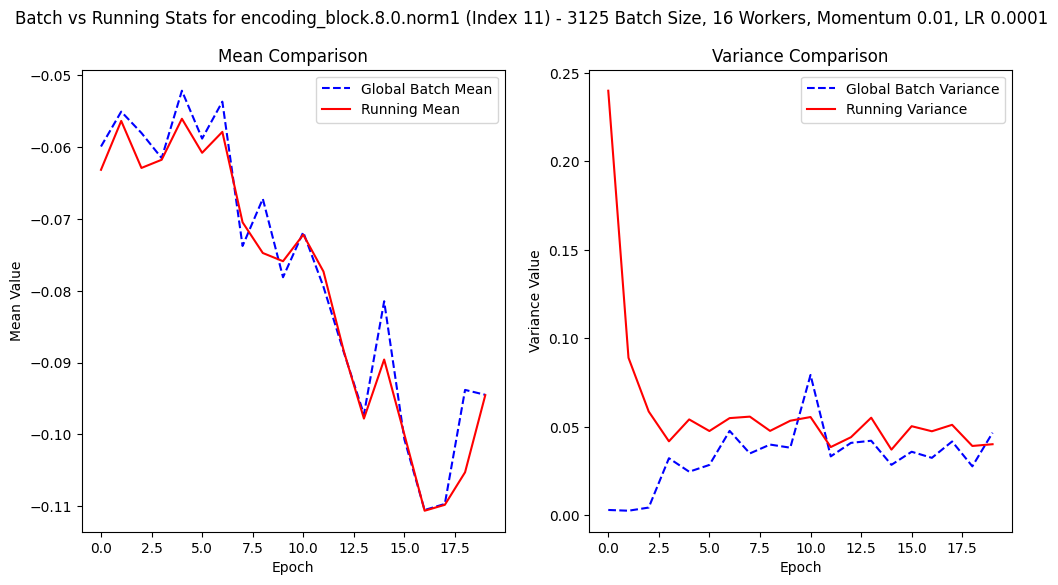

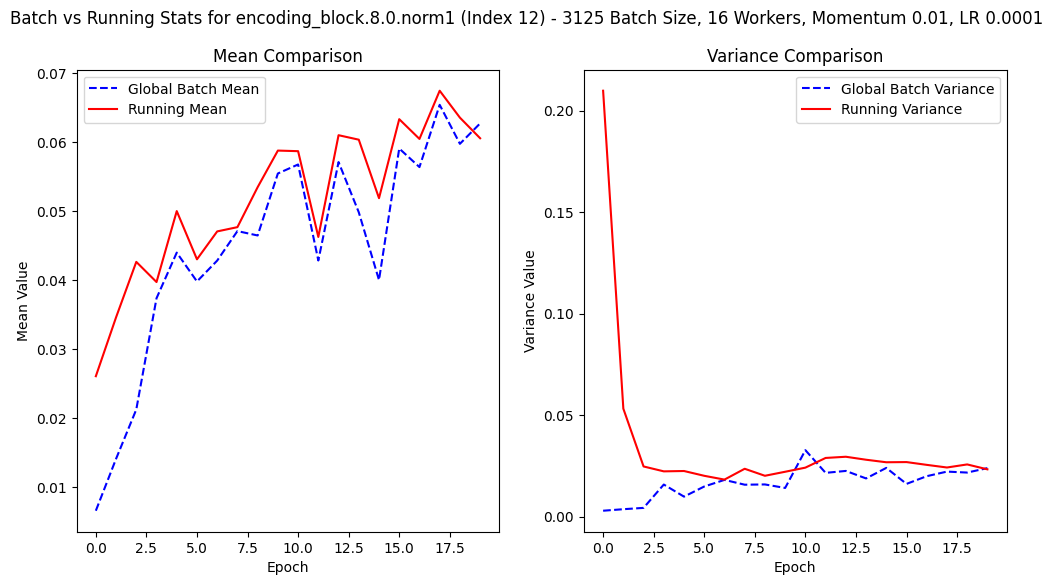

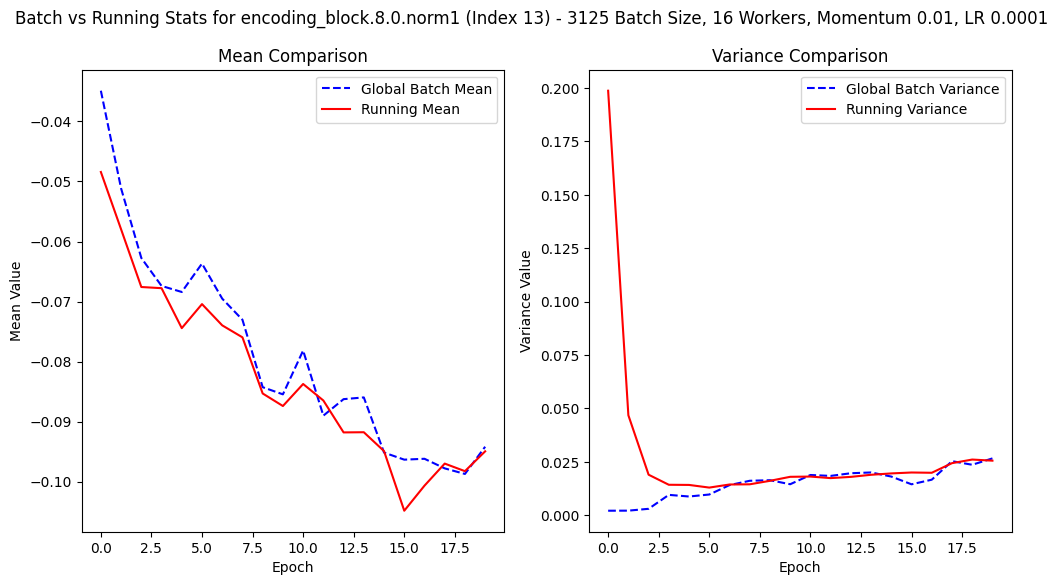

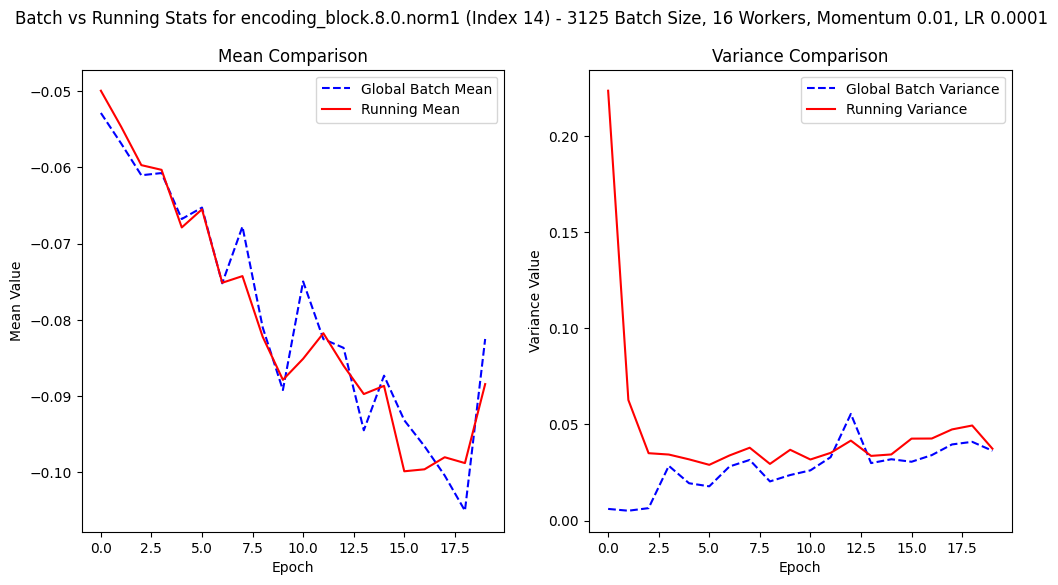

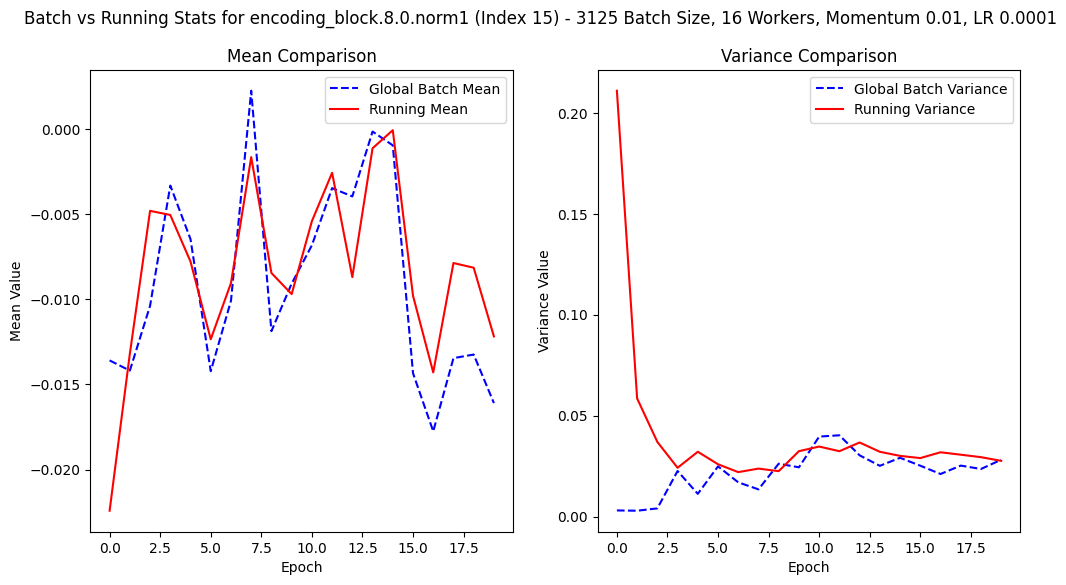

In [65]:
import ast 
def plot_batch_vs_running_stats(batch_stats_log, layer_name, sample, index=1):

    epochs = []
    global_batch_mean = []
    global_batch_var = []
    running_mean = []
    running_var = []
    with open(batch_stats_log, 'r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            if str(row['layer_name']) == layer_name:
                epochs.append(int(row['epoch']))
                global_batch_mean_list = ast.literal_eval(str(row['global_batch_mean'].split()[1:-2]))
                global_batch_mean_arr = np.array([float(g) for g in global_batch_mean_list])
                global_batch_mean.append(float(global_batch_mean_arr[index]))
                global_batch_var_list = ast.literal_eval(str(row['global_batch_var'].split()[1:-2]))
                global_batch_var_arr = np.array([float(g) for g in global_batch_var_list])
                global_batch_var.append(float(global_batch_var_arr[index]))
                running_mean_list = ast.literal_eval(str(row['running_mean'].split()[1:-2]))
                running_mean_arr = np.array([float(g) for g in running_mean_list])
                running_mean.append(float(running_mean_arr[index]))
                running_var_list = ast.literal_eval(str(row['running_var'].split()[1:-2]))
                running_var_arr = np.array([float(g) for g in running_var_list])
                running_var.append(float(running_var_arr[index]))
            else: continue

    fig, ax = plt.subplots(1, 2, figsize=(12,6))
    fig.suptitle(f'Batch vs Running Stats for {layer_name} (Index {index}) - ' + sample)
    ax[0].plot(epochs, global_batch_mean, label='Global Batch Mean', color='blue', linestyle='--')
    ax[0].plot(epochs, running_mean, label='Running Mean', color='red', linestyle='-')
    ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Mean Value')
    ax[0].set_title(f'Mean Comparison')
    ax[0].legend()      

    ax[1].plot(epochs, global_batch_var, label='Global Batch Variance', color='blue', linestyle='--')
    ax[1].plot(epochs, running_var, label='Running Variance', color='red', linestyle='-')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Variance Value')
    ax[1].set_title(f'Variance Comparison')
    ax[1].legend()
    plt.show()      

plot_batch_vs_running_stats(batch_stats_log, 'encoding_block.2.1.norm2', '3125 Batch Size, 16 Workers, Momentum 0.01, LR 0.0001', index=0)
plot_batch_vs_running_stats(batch_stats_log, 'encoding_block.2.1.norm2', '3125 Batch Size, 16 Workers, Momentum 0.01, LR 0.0001', index=1)
plot_batch_vs_running_stats(batch_stats_log, 'encoding_block.2.1.norm2', '3125 Batch Size, 16 Workers, Momentum 0.01, LR 0.0001', index=2)
plot_batch_vs_running_stats(batch_stats_log, 'encoding_block.2.1.norm2', '3125 Batch Size, 16 Workers, Momentum 0.01, LR 0.0001', index=3)
plot_batch_vs_running_stats(batch_stats_log, 'encoding_block.2.1.norm2', '3125 Batch Size, 16 Workers, Momentum 0.01, LR 0.0001', index=4)
plot_batch_vs_running_stats(batch_stats_log, 'encoding_block.2.1.norm2', '3125 Batch Size, 16 Workers, Momentum 0.01, LR 0.0001', index=5)

plot_batch_vs_running_stats(batch_stats_log, 'encoding_block.8.0.norm1', '3125 Batch Size, 16 Workers, Momentum 0.01, LR 0.0001', index=10)
plot_batch_vs_running_stats(batch_stats_log, 'encoding_block.8.0.norm1', '3125 Batch Size, 16 Workers, Momentum 0.01, LR 0.0001', index=11)
plot_batch_vs_running_stats(batch_stats_log, 'encoding_block.8.0.norm1', '3125 Batch Size, 16 Workers, Momentum 0.01, LR 0.0001', index=12)
plot_batch_vs_running_stats(batch_stats_log, 'encoding_block.8.0.norm1', '3125 Batch Size, 16 Workers, Momentum 0.01, LR 0.0001', index=13)
plot_batch_vs_running_stats(batch_stats_log, 'encoding_block.8.0.norm1', '3125 Batch Size, 16 Workers, Momentum 0.01, LR 0.0001', index=14)
plot_batch_vs_running_stats(batch_stats_log, 'encoding_block.8.0.norm1', '3125 Batch Size, 16 Workers, Momentum 0.01, LR 0.0001', index=15)



In [ ]:
# Load model with eval mode off
'''torch.cuda.empty_cache()
# Get parameters
yaml_config = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/configs/default_sheep.yaml'
config = 'default'
params = ParseYAML(os.path.abspath(yaml_config), config)

# Initialize model 
if torch.cuda.is_available():
    device = torch.cuda.current_device()
else:
    device = torch.device('cpu')

model = models.sheep_cnn.sheep_cnn(params).to(device)
#model = torch.nn.SyncBatchNorm.convert_sync_batchnorm(model)

# get model dictionary
#checkpoint_path = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_CHECK_REPRO_3A/checkpoints/ckpt_epoch_5_iters1500.tar'
#checkpoint_path = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_OFF_3C/checkpoints/ckpt_epoch_5_iters1500.tar'
checkpoint_path = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_ON_SYNC_BN_MOMENTUM_0.01_LOG_BN_STATS_4D/checkpoints/ckpt_epoch_0_iters_250_best.tar'


checkpoint = torch.load(checkpoint_path, weights_only=True) 
try:
    model.load_state_dict(checkpoint['model_state'])
except:
    new_state_dict = OrderedDict()
    for key, val in checkpoint['model_state'].items():
        name = key[7:]
        new_state_dict[name] = val 
    model.load_state_dict(new_state_dict)'''


In [ ]:
# Look at parameters
'''print("Model's state_dict:")
for param_tensor in model.state_dict():
    print(param_tensor, "\t", model.state_dict()[param_tensor].size())'''

Model's state_dict:
input_layer.kernel 	 torch.Size([343, 4, 32])
encoding_conv.0.0.bn.weight 	 torch.Size([32])
encoding_conv.0.0.bn.bias 	 torch.Size([32])
encoding_conv.0.0.bn.running_mean 	 torch.Size([32])
encoding_conv.0.0.bn.running_var 	 torch.Size([32])
encoding_conv.0.0.bn.num_batches_tracked 	 torch.Size([])
encoding_conv.0.2.kernel 	 torch.Size([8, 32, 64])
encoding_conv.1.0.bn.weight 	 torch.Size([64])
encoding_conv.1.0.bn.bias 	 torch.Size([64])
encoding_conv.1.0.bn.running_mean 	 torch.Size([64])
encoding_conv.1.0.bn.running_var 	 torch.Size([64])
encoding_conv.1.0.bn.num_batches_tracked 	 torch.Size([])
encoding_conv.1.2.kernel 	 torch.Size([8, 64, 96])
encoding_conv.2.0.bn.weight 	 torch.Size([96])
encoding_conv.2.0.bn.bias 	 torch.Size([96])
encoding_conv.2.0.bn.running_mean 	 torch.Size([96])
encoding_conv.2.0.bn.running_var 	 torch.Size([96])
encoding_conv.2.0.bn.num_batches_tracked 	 torch.Size([])
encoding_conv.2.2.kernel 	 torch.Size([8, 96, 128])
encoding_conv.3

In [ ]:
# Look at parameters
'''print("Model's state_dict:")
for param_tensor in model.state_dict():
    if "bn" in param_tensor:
        print(param_tensor, "\t", model.state_dict()[param_tensor])'''

Model's state_dict:
encoding_conv.0.0.bn.weight 	 tensor([0.9956, 0.9952, 1.0067, 0.9919, 0.9957, 0.9938, 1.0028, 0.9946, 0.9985,
        1.0066, 1.0031, 0.9967, 0.9960, 1.0040, 0.9924, 0.9925, 0.9951, 0.9953,
        0.9957, 0.9934, 1.0055, 0.9934, 1.0069, 1.0049, 1.0050, 1.0034, 0.9933,
        0.9925, 1.0046, 1.0062, 1.0024, 1.0044], device='cuda:0')
encoding_conv.0.0.bn.bias 	 tensor([-0.0046, -0.0067,  0.0061, -0.0065, -0.0065, -0.0058,  0.0044, -0.0057,
        -0.0041, -0.0043,  0.0021,  0.0067,  0.0075,  0.0043, -0.0064, -0.0062,
        -0.0068, -0.0068, -0.0047, -0.0046,  0.0050, -0.0047,  0.0040, -0.0077,
         0.0059, -0.0039, -0.0041, -0.0071, -0.0054, -0.0051, -0.0050,  0.0070],
       device='cuda:0')
encoding_conv.0.0.bn.running_mean 	 tensor([-0.1466,  0.0304,  0.4847,  0.4298, -0.2235, -0.3786,  0.2433,  0.3990,
        -0.1445,  0.1959, -0.0372,  0.4058, -0.2523,  0.1646, -0.2487, -0.1953,
        -0.3433,  0.0658,  0.1012, -0.5800, -0.4495, -0.3597,  0.1481,  0.1

tensor([ 0.3188,  0.0274,  0.5088,  0.2735,  0.1719, -0.2800,  0.2250,  0.0423,
        -0.1127,  0.1944, -0.0024, -0.4145,  0.1771, -0.5834,  0.2339,  0.4153,
        -0.1953,  0.3943, -0.3230,  0.6093, -0.2467,  0.4234,  0.3285,  0.6323,
         0.1345,  0.0496, -0.1217,  0.1508,  0.0839,  0.4380,  0.0995,  0.7307,
         0.6803,  0.1195,  0.3299,  0.3511,  0.2060,  0.4176, -0.0010,  0.0723,
         0.0437,  0.0284, -0.2210,  0.3154,  0.0842,  0.6042, -0.2973, -0.3534,
        -0.2954, -0.3720,  0.5617,  0.0800, -0.0882, -0.0360, -0.1601, -0.0263,
         0.0803, -0.3619,  0.3037,  0.0627, -0.2823,  0.2939,  0.1097,  0.1701],
       device='cuda:0')
encoding_conv.1.0.bn.running_var 	 tensor([ 4.5693,  0.8083,  7.9837,  4.6847,  1.7456,  3.1366,  2.8320,  0.9732,
         1.5208,  2.8846,  0.6725,  4.7139,  2.9206,  9.5836,  2.9372,  6.7413,
         1.5324,  5.3967,  3.6953, 13.2146,  2.0422,  6.9520,  4.6579, 11.6919,
         1.5615,  1.0769,  1.1573,  1.3685,  1.1975,  5.2268